<a href="https://colab.research.google.com/github/Andreasaldivar/GOOGLE-COLLAB-QUERY/blob/main/SQL_FUNNEL_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# __📊SQL WORK ENVIROMENT. E-COMMERCE FUNNEL DATA ANALYSIS 🛍️🧑‍💻__
---


## 🚨 __¿Cómo usar este archivo?__ 🤷🏻‍♂️

<p align="justify">
El presente archivo se constituye como una herramienta generadora de ambiente para el desarrollo de código SQL en Google Colab. Sus objetivo son: </p>

* <p align="justify"> Permitir al estudiante acceder a una base de datos que cuenta con más de 800,000 registros asociados a distintas variables relativas al rubro de prestación de servicios de salud (rubro hospitalario) :. </p>

* <p align="justify"> Generar un ambiente del trabajo donde los estudiantes puedan escribir, depurar y generar código SQL para realizar cosultas sobre la base de datos generada. </p>

* <p align="justify"> Aprender a usar SQL como herramienta de comunicación de insights y como pueden utilizarse para responder la pregunta de negocio o hipótesis que sea de interés para los stakeholders.
</p>

* <p align="justify">  Generar instancias que impliquen el manejo simultaneo de múltiples tablas en una base de datos.
</p>

<p align="justify">
El contexto viene dado por una 👉<b><a href="https://github.com/hector1994/e_commerce_funnel_data_generator/blob/master/customer_journey_data_generator_final_mejorado.ipynb">generación de data de eventos  de e-commerce</a></b> 👈, que tiene por finalidad generar una instancia que permite al estudiante comprender la relación entre tablas, generación de consultas SQL de distinta complejidad, uso de CTE, filtros, sumarios, subconsultas, entro otros conceptos.

Adicionalmente, se entenderá el concepto de análisis de funnel, el cual es un concepto bastante común en el ámbito del comercio digital y como acceder a este tipo de insights se constituyen como una gran herramienta para la administración general de un negocio de comercio virtual.
</p>

---

##🖊️📖✏️📚 __INSTRUCCIONES DE USO__ 📋

 <p align="justify">

* __STEP 1️⃣:__ <p align="justify">  El chunk de código que viene a continuación tiene <b>dos funciones principales:</b>
</p>

<p align="justify">

**(1) Conectar** nuestro entorno con las bases de datos generadas para nuestro propósito de aprendizaje.
</p>

<p align="justify">

**(2) Generar un entorno de programación en SQL** idéntico a los motores frecuentemente usados en la industrial.
</p>

<p align="justify">
<b>Si es de su interés</b>, puedes hacer click en el botón ✨<b><font color="green">Mostrar código</font></b>✨, para poder ver con todo detalle el proceso mencionado en (1) y (2). Si no es así, simplemente omita esta opción. Sea cual sea el caso, <b><font color="red">debe dar click en el botón de run</font> </b> para poder generar la base de datos y activar el ambiente.
</p>

<p align = "justify">
Listo! La base de datos ha sido generada y ya podemos ver las tablas disponibles (rutas). También el ambiente para poder generar SQL-queries ha sido activado.
</p>

* __STEP 2️⃣:__ <p align="justify">

 Listo! Luego del paso anterior, ya puedes comenzar a generar consultas en este Google Colab y consultar la base de datos que ha sido generada (usando sus rutas). Para eso, simplemente debemos crear un nuevo chunck de código y escribir la <b><font color="cian">palabra mágica:</font></b> <b><font color="blue">%%sql</font></b>✨ en nuestro chunck de código y listo ✅, en ese chunck puedes ejecutar código SQL como lo harías en cualquier plataforma 🛢️.
</p>


In [1]:
#@title 🛢️📊 __STEP 1:__ Conectémonos a nuestra base de datos y activemos nuestro ambiente 🚀 { display-mode: "form" }
import pandas as pd
import sqlite3
from tqdm.notebook import tqdm
from IPython.core.magic import register_cell_magic
from IPython.display import display, HTML, clear_output

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

# 1. Configuración de enlaces (Datasets Sincronizados en GitHub)
datasets = {
    'ecommerce_events': "https://media.githubusercontent.com/media/hector1994/e_commerce_funnel_data_generator/refs/heads/master/data_clase_sql_final.csv",
    'dim_products': "https://media.githubusercontent.com/media/hector1994/e_commerce_funnel_data_generator/refs/heads/master/dim_products.csv",
    'dim_customers': "https://media.githubusercontent.com/media/hector1994/e_commerce_funnel_data_generator/refs/heads/master/dim_customers.csv"
}

# 2. Conexión a la base de datos en memoria
connector = sqlite3.connect(':memory:', check_same_thread=False)

# 3. Proceso de carga con Barra de Progreso
print("⬇️🗂️ Descargando y sincronizando Datasets (Hechos + Dimensiones).....🔄⚙️")
summary_data = []

for name, url in tqdm(datasets.items(), desc="Cargando Tablas"):
    try:
        # Descarga de datos
        df = pd.read_csv(url)

        # Conversión de fechas para eventos y clientes
        if name == 'ecommerce_events' and 'event_timestamp' in df.columns:
            df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

        if name == 'dim_customers' and 'registration_date' in df.columns:
            df['registration_date'] = pd.to_datetime(df['registration_date'])

        # Carga a SQLite
        df.to_sql(name, connector, index=False, if_exists='replace', chunksize=10000)

        summary_data.append({
            "Table Name": f"{name}",
            "Rows": f"{len(df):,}",
            "Columns": len(df.columns)
        })
    except Exception as e:
        print(f"❌ Error cargando {name}: {e}")

# 4. Definición de la "Palabra mágica" %%sql
@register_cell_magic
def sql(line, cell):
    try:
        resultado = pd.read_sql(cell, connector)
        clear_output(wait=True)
        display(HTML("<b style='color: #4CAF50;'>✅ Query completed successfully:</b>"))
        return display(resultado)
    except Exception as e:
        clear_output(wait=True)
        display(HTML(f"<b style='color: #F44336;'>❌ Query execution failed:</b><br><code style='color: grey;'>{str(e)}</code>"))

# 5. Interfaz final
clear_output()
display(HTML("<h2 style='color: #8e62f3'>✨ Database initialized: Full Star Schema ✨</h2>"))
display(HTML("<p>Tables ready: <b>ecommerce_events</b>, <b>dim_products</b>, and <b>dim_customers</b>.</p>"))

display(pd.DataFrame(summary_data))
print("\n ✨🚀 SYSTEM READY! START ANALYZING THE FUNNEL! 🚀✨")

,Table Name,Rows,Columns
0,ecommerce_events,"1,550,127",15
1,dim_products,"1,401",8
2,dim_customers,"89,735",10



 ✨🚀 SYSTEM READY! START ANALYZING THE FUNNEL! 🚀✨


#### 📶 __Análisis de Funnels y Micro-Momentos: Desvelando la Fuga de Conversión__💎

<p align = 'justify'>
El análisis de funnel o embudo de conversión es una de las piedras angulares en el trabajo de un Data Analyst, especialmente en entornos de e-commerce y productos digitales. Este proceso se basa en el seguimiento de una serie de eventos específicos, que son acciones discretas realizadas por el usuario, como <code>page_view </code>, <code>add_to_cart</code> y finalmente <code>purchase</code>. El concepto de efecto funnel describe cómo el volumen de usuarios disminuye inevitablemente a medida que avanzan en el flujo; por ejemplo, miles de personas pueden ver un producto, pero solo una fracción lo añade al carrito y un grupo aún menor completa el pago. La diferencia entre los usuarios que inician un paso y los que completan el siguiente se conoce como fuga o churn del funnel. Identificar dónde es más pronunciada esta fuga permite al analista señalar cuellos de botella críticos, donde pequeños ajustes en la interfaz o en la estrategia de marketing podrían recuperar ingresos significativos.
 </p>

 <p align = 'justify'>
 En la práctica técnica, el uso de SQL es la herramienta estándar y más potente para construir estos modelos de análisis. Un Data Analyst utiliza SQL para segmentar estos embudos por dimensiones como el país, el tipo de dispositivo o el nivel de membresía (Bronze, Silver, Gold), lo que permite descubrir si la fuga es un problema técnico de una plataforma específica o una falta de interés de un segmento de clientes particular. La capacidad de transformar millones de registros crudos en una tabla limpia de porcentajes de conversión es lo que separa un reporte descriptivo de uno verdaderamente accionable.
 </p>

 <p align = 'justify'>
 La frecuencia con la que se requiere este análisis en la industria es altísima, siendo prácticamente una tarea diaria en equipos de Producto y Crecimiento (Growth). En un mercado competitivo, las empresas no pueden permitirse ignorar por qué están perdiendo clientes en medio de un proceso de compra. Los beneficios de dominar esta técnica son directos: permite la optimización de la tasa de conversión (CRO), justifica inversiones en rediseño de UX basadas en datos duros y mejora el retorno de inversión publicitaria (ROAS). Al final del día, el análisis de funnel no solo reporta qué sucedió, sino que proporciona el mapa necesario para que el negocio sepa exactamente dónde intervenir para maximizar la retención y el valor de vida del cliente (LTV).</p>

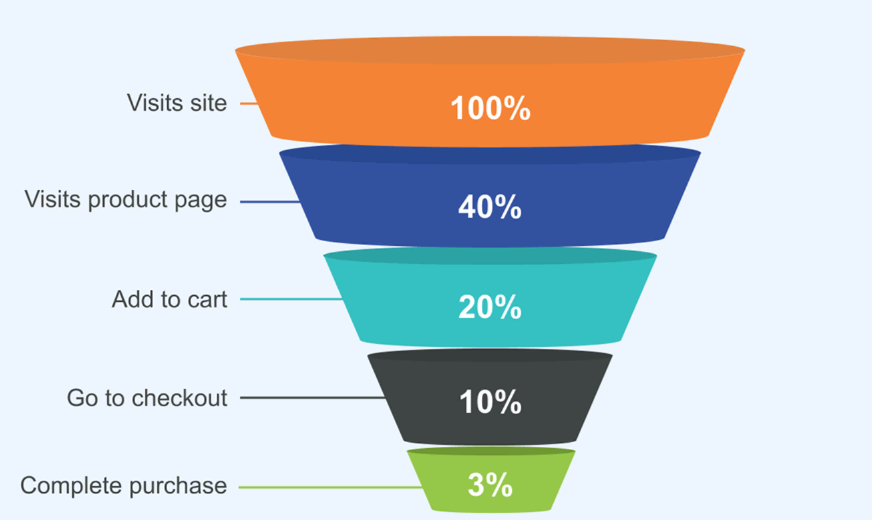


#### 🗺️ __Customer Journey: Definición de Eventos del Embudo__ 🔍
#### 🛠️ Diccionario del Flujo de Usuario

| ID | Evento | Descripción Técnica | Clasificación |
| :--- | :--- | :--- | :--- |
| **0** | <font color="#7abaff">`home_page`</font> | Carga inicial del sitio. Punto de partida de la sesión. | <font color="#7abaff">Navegación</font> |
| **1** | <font color="#7abaff">`log_in`</font> | El usuario se identifica. Permite rastrear su historial. | <font color="#7abaff">Identificación</font> |
| **2** | <font color="#7abaff">`page_view`</font> | Visualización de subpáginas o contenido informativo. | <font color="#7abaff">Navegación</font> |
| **3** | <font color="#ffd43b">`scroll`</font> | Interacción de lectura. Indica compromiso con el contenido. | <font color="#ffd43b">Interacción</font> |
| **4** | <font color="#ffd43b">`click_product`</font> | Interés específico en un ítem del catálogo. | <font color="#ffd43b">Interacción</font> |
| **5** | <font color="#ffd43b">`add_to_cart`</font> | Intención de compra. El producto entra en la cesta. | <font color="#ffd43b">Interés Alto</font> |
| **6** | <font color="#ff6b6b">`begin_checkout`</font> | Inicio del proceso de pago y logística de envío. | <font color="#ff6b6b">Checkout</font> |
| **7** | <font color="#ff6b6b">`end_checkout`</font> | Revisión final. Último paso antes de procesar el pago. | <font color="#ff6b6b">Checkout</font> |
| **8** | <font color="#8ce99a">`purchase`</font> | **Conversión final.** Se registra el `payment_method` e ingreso. | <font color="#8ce99a">Conversión</font> |

---

###  👩🏻‍💻🕵🏻‍♂️ __STEP 2: Comencemos a hacer consultas!__ 🗂️📡👩🏻‍💻

In [2]:
%%sql
SELECT * FROM ecommerce_events LIMIT 10

,event_type_id,user_id,session_id,event_name,event_timestamp,time_zone,country,device,traffic_source,category,sku,cart_id,payment_method,units,amount
0,4,11053828,SESS-11053828-4,scroll,2026-01-11 01:10:31,UTC-5,Colombia,Desktop,Facebook,Clothing,SKU-2009,None,None,0,0.00
1,1,11031713,SESS-11031713-2,home_page,2026-01-14 14:00:40,UTC-6,México,Tablet,Email,None,None,None,None,0,0.00
2,2,11050906,SESS-11050906-3,log_in,2026-01-15 07:01:05,UTC-6,México,Tablet,Google,None,None,None,None,0,0.00
3,1,11128908,SESS-11128908-2,home_page,2026-01-27 22:00:17,UTC-3,Chile,Mobile,Facebook,None,None,None,None,0,0.00
4,5,11131545,SESS-11131545-3,click_product,2026-01-16 18:15:16,UTC-3,Argentina,Tablet,Google,Clothing,SKU-3798,None,None,0,0.00
5,3,11116039,SESS-11116039-4,page_view,2026-01-31 11:05:42,UTC-3,Argentina,Tablet,Facebook,Electronics,SKU-1823,None,None,0,0.00
6,6,11154443,SESS-11154443-2,add_to_cart,2026-01-06 18:15:18,UTC-6,México,Tablet,Google,Home,SKU-1475,CART-185435,None,1,491.69
7,3,11078425,SESS-11078425-3,page_view,2026-01-11 16:07:03,UTC+1,España,Desktop,Email,Home,SKU-4663,None,None,0,0.00
8,3,11134697,SESS-11134697-1,page_view,2026-01-25 15:07:52,UTC-3,Chile,Desktop,Facebook,Clothing,SKU-2644,None,None,0,0.00
9,2,11122720,SESS-11122720-1,log_in,2026-01-18 10:01:37,UTC-6,México,Mobile,Facebook,None,None,None,None,0,0.00


In [3]:
%%sql
--FECHA INICIAL Y FINAL DE REGISTROS DE INFORMACIÓN - ENERO 2026
SELECT
MIN(event_timestamp) AS fecha_inicial,
MAX(event_timestamp) AS fecha_final
FROM ecommerce_events

,fecha_inicial,fecha_final
0,2026-01-01 00:00:10,2026-01-31 23:22:24


In [4]:
%%sql
--- CONSULTAS ESCALARES
SELECT
COUNT(*) AS total_registros -- PARA DETERMINAR EL TOTAL DE REGISTROS COUNT(*) -- EVENTOS (HOME PAGE, ADD_TO_CART, PURCHASE, CLICK_PRODUCT)
FROM ecommerce_events

,total_registros
0,1550127


In [5]:
%%sql
-- CANTIDAD DE EVENTOS: TENEMOS 9 EVENTOS DISTINTOS
SELECT
COUNT(DISTINCT(event_name))
FROM ecommerce_events

,COUNT(DISTINCT(event_name))
0,9


In [6]:
%%sql

---PAISES A DISPOSICIÓN: ARG-MEX-COL-CHL-ESP
SELECT
country AS pais,
COUNT(DISTINCT(user_id)) AS usuarios_totales,
COUNT(*) AS eventos_conteo
FROM ecommerce_events GROUP BY 1 ORDER BY 2 DESC

,pais,usuarios_totales,eventos_conteo
0,España,32656,310951
1,Chile,32635,311084
2,México,32535,310222
3,Argentina,32475,309095
4,Colombia,32373,308775


In [7]:
%%sql
--CONTEO DE USUARIOS Y EVENTOS POR DISPOSITIVO Y POR PAIS.
SELECT
DISTINCT(device) AS dispositivo,
country AS pais,

COUNT(DISTINCT(user_id)) AS usuarios_totales,
COUNT(*) AS eventos_conteo
FROM ecommerce_events GROUP BY 1,2
ORDER BY 1 DESC

,dispositivo,pais,usuarios_totales,eventos_conteo
0,Tablet,Argentina,10681,101854
1,Tablet,Chile,10937,104634
2,Tablet,Colombia,10820,102707
3,Tablet,España,10913,104390
4,Tablet,México,11032,105423
5,Mobile,Argentina,10925,103725
6,Mobile,Chile,10841,103615
7,Mobile,Colombia,10684,102452
8,Mobile,España,10979,104301
9,Mobile,México,10694,102171


In [8]:
%%sql
SELECT * FROM ecommerce_events LIMIT 10

,event_type_id,user_id,session_id,event_name,event_timestamp,time_zone,country,device,traffic_source,category,sku,cart_id,payment_method,units,amount
0,4,11053828,SESS-11053828-4,scroll,2026-01-11 01:10:31,UTC-5,Colombia,Desktop,Facebook,Clothing,SKU-2009,None,None,0,0.00
1,1,11031713,SESS-11031713-2,home_page,2026-01-14 14:00:40,UTC-6,México,Tablet,Email,None,None,None,None,0,0.00
2,2,11050906,SESS-11050906-3,log_in,2026-01-15 07:01:05,UTC-6,México,Tablet,Google,None,None,None,None,0,0.00
3,1,11128908,SESS-11128908-2,home_page,2026-01-27 22:00:17,UTC-3,Chile,Mobile,Facebook,None,None,None,None,0,0.00
4,5,11131545,SESS-11131545-3,click_product,2026-01-16 18:15:16,UTC-3,Argentina,Tablet,Google,Clothing,SKU-3798,None,None,0,0.00
5,3,11116039,SESS-11116039-4,page_view,2026-01-31 11:05:42,UTC-3,Argentina,Tablet,Facebook,Electronics,SKU-1823,None,None,0,0.00
6,6,11154443,SESS-11154443-2,add_to_cart,2026-01-06 18:15:18,UTC-6,México,Tablet,Google,Home,SKU-1475,CART-185435,None,1,491.69
7,3,11078425,SESS-11078425-3,page_view,2026-01-11 16:07:03,UTC+1,España,Desktop,Email,Home,SKU-4663,None,None,0,0.00
8,3,11134697,SESS-11134697-1,page_view,2026-01-25 15:07:52,UTC-3,Chile,Desktop,Facebook,Clothing,SKU-2644,None,None,0,0.00
9,2,11122720,SESS-11122720-1,log_in,2026-01-18 10:01:37,UTC-6,México,Mobile,Facebook,None,None,None,None,0,0.00


In [9]:
%%sql

SELECT
      DISTINCT traffic_source AS fuente_de_trafico,

       COUNT(DISTINCT(user_id)) AS conteo_usuarios,
       COUNT(*) AS eventos_totales

       FROM ecommerce_events
       GROUP BY 1
       ORDER BY 2 DESC

,fuente_de_trafico,conteo_usuarios,eventos_totales
0,Google,40782,389415
1,Facebook,40751,387435
2,Direct,40581,386643
3,Email,40560,386634


In [10]:
%%sql

SELECT
country AS pais,

COUNT(*) AS product_views
FROM ecommerce_events
WHERE event_name = 'product_view' GROUP BY 1 ORDER BY 2 DESC

,pais,product_views


#### __CONSULTAS SQL ESCALARES__

In [11]:
%%sql

SELECT
country,
COUNT(*) AS compras,
100.0*COUNT(*)/(SELECT COUNT(*) AS total_compras FROM ecommerce_events WHERE event_name = 'purchase') AS porcentaje_compras
FROM ecommerce_events
WHERE event_name = 'purchase'
GROUP BY 1
ORDER BY 2 DESC


,country,compras,porcentaje_compras
0,Chile,2494,20.494700
1,Colombia,2458,20.198866
2,Argentina,2454,20.165996
3,España,2425,19.927685
4,México,2338,19.212754


In [12]:
%%sql
--SUMARIO O CONTEO DE EVENTOS.

SELECT
DATE(event_timestamp) AS fecha,
(SELECT COUNT(*) FROM ecommerce_events WHERE event_name  = 'product_view'   AND DATE(event_timestamp) = '2026-01-01')        AS product_view,
(SELECT COUNT(*) FROM ecommerce_events WHERE event_name  = 'add_to_cart'    AND DATE(event_timestamp) = '2026-01-02')        AS add_cart,
(SELECT COUNT(*) FROM ecommerce_events WHERE event_name  = 'begin_checkout' AND DATE(event_timestamp) = '2026-01-03')        AS begin_checkout,
(SELECT COUNT(*) FROM ecommerce_events WHERE event_name  = 'purchase'       AND DATE(event_timestamp) = '2026-01-04')        AS purchase
FROM ecommerce_events
GROUP BY 1

,fecha,product_view,add_cart,begin_checkout,purchase
0,2026-01-01,0,3291,1953,355
1,2026-01-02,0,3291,1953,355
2,2026-01-03,0,3291,1953,355
3,2026-01-04,0,3291,1953,355
4,2026-01-05,0,3291,1953,355
5,2026-01-06,0,3291,1953,355
6,2026-01-07,0,3291,1953,355
7,2026-01-08,0,3291,1953,355
8,2026-01-09,0,3291,1953,355
9,2026-01-10,0,3291,1953,355


In [ ]:
%%sql
-- product_view 	add_cart 	begin_checkout end_checkout 	purchase
WITH
---CREACIÓN TABLA DE VISTA DE PRODUCTOS

product_view AS (
  SELECT
  DATE(event_timestamp) AS fecha,
  COUNT(*) AS conteo_product_views
  FROM ecommerce_events
  WHERE event_name = 'product_view' AND country IN ('México', 'Chile') GROUP BY 1 ORDER BY 1 DESC
),


---CREACIÓN TABLA DE BEGIN CHECKOUT
begin_checkout AS (
  SELECT
  DATE(event_timestamp) AS fecha,
  COUNT(*) AS conteo_begin_checkout
  FROM ecommerce_events
  WHERE event_name = 'begin_checkout' AND country IN ('México', 'Chile') GROUP BY 1 ORDER BY 1 DESC
),
--CREACIÓN TABLA DE Adiciones al carrito
add_to_cart AS (
  SELECT
  DATE(event_timestamp) AS fecha,
  COUNT(*) AS conteo_add_to_cart
  FROM  ecommerce_events
  WHERE event_name = 'add_to_cart' AND country IN ('México', 'Chile') GROUP BY 1 ORDER BY 1 DESC
),
-- CREACION TABLA DE FIN CHECKOUT
end_checkout AS (
  SELECT
  DATE(event_timestamp) AS fecha,
  COUNT(*) AS conteo_end_checkout
  FROM ecommerce_events
  WHERE event_name = 'end_checkout' AND country IN ('México', 'Chile') GROUP BY 1 ORDER BY 1 DESC
),
--CRECIÓN TABLA COMPRAS
purchase AS (
  SELECT
  DATE(event_timestamp) AS fecha,
  COUNT(*) AS conteo_purchase
  FROM ecommerce_events
  WHERE event_name  = 'purchase' AND country IN ('México', 'Chile')  GROUP BY 1 ORDER BY 1 DESC
  )

SELECT a.fecha,
       a.conteo_product_views,
       b.conteo_add_to_cart,
       c.conteo_begin_checkout,
       d.conteo_end_checkout,
       e.conteo_purchase
FROM product_view AS a
INNER JOIN add_to_cart AS b ON a.fecha = b.fecha
INNER JOIN begin_checkout AS c ON b.fecha = c.fecha
INNER JOIN end_checkout AS d ON c.fecha = d.fecha
INNER JOIN purchase AS e ON d.fecha = e.fecha


,fecha,conteo_product_views,conteo_add_to_cart,conteo_begin_checkout,conteo_end_checkout,conteo_purchase
0,2026-02-01,26,11,9,10,10
1,2026-01-31,9535,2536,2163,1952,1844
2,2026-01-30,9524,2628,2251,2013,1917
3,2026-01-29,9622,2667,2281,2055,1955
4,2026-01-28,9650,2568,2176,1947,1845
5,2026-01-27,9788,2692,2254,2031,1923
6,2026-01-26,9669,2643,2246,2005,1910
7,2026-01-25,9448,2563,2174,1928,1825
8,2026-01-24,9333,2549,2194,1970,1851
9,2026-01-23,9477,2551,2158,1927,1813


In [14]:
%%sql
SELECT
  DATE(event_timestamp) AS fecha,
  COUNT(*) AS conteo_product_views
  FROM ecommerce_events
  WHERE event_name = 'product_view' GROUP BY 1 ORDER BY 2 DESC

,fecha,conteo_product_views


In [ ]:
%%sql
SELECT country, COUNT(*) FROM ecommerce_events WHERE event_name = 'begin_checkout' GROUP BY 1 ORDER BY 2 DESC

,country,COUNT(*)
0,México,57627
1,España,36277
2,Colombia,21673
3,Argentina,17290
4,Chile,11330


In [16]:
%%sql
SELECT
user_id,
event_timestamp,
session_id,
event_name,
country,
traffic_source

FROM ecommerce_events LIMIT 10



,user_id,event_timestamp,session_id,event_name,country,traffic_source
0,11053828,2026-01-11 01:10:31,SESS-11053828-4,scroll,Colombia,Facebook
1,11031713,2026-01-14 14:00:40,SESS-11031713-2,home_page,México,Email
2,11050906,2026-01-15 07:01:05,SESS-11050906-3,log_in,México,Google
3,11128908,2026-01-27 22:00:17,SESS-11128908-2,home_page,Chile,Facebook
4,11131545,2026-01-16 18:15:16,SESS-11131545-3,click_product,Argentina,Google
5,11116039,2026-01-31 11:05:42,SESS-11116039-4,page_view,Argentina,Facebook
6,11154443,2026-01-06 18:15:18,SESS-11154443-2,add_to_cart,México,Google
7,11078425,2026-01-11 16:07:03,SESS-11078425-3,page_view,España,Email
8,11134697,2026-01-25 15:07:52,SESS-11134697-1,page_view,Chile,Facebook
9,11122720,2026-01-18 10:01:37,SESS-11122720-1,log_in,México,Facebook


In [24]:
--
-- product_view 	add_cart 	begin_checkout end_checkout 	purchase
--WITH
---CREACIÓN TABLA DE VISTA DE PRODUCTOS
--product_view_tabla AS (
  --SELECT *
 -- FROM ecommerce_events
 -- WHERE event_name = 'product_view'
--),
---CREACIÓN TABLA DE BEGIN CHECKOUT
--egin_checkout AS (
 -- SELECT *
 -- FROM ecommerce_events
--  WHERE event_name = 'begin_checkout'
--),
--CREACIÓN TABLA DE Adiciones al carrito
--add_to_cart AS (
 -- SELECT *
 -- FROM  ecommerce_events
  --WHERE event_name = 'add_to_cart'
--),
-- CREACION TABLA DE FIN CHECKOUT
--end_checkout AS (
  --SELECT *
  --FROM ecommerce_events
  --WHERE event_name = 'end_checkout'
--),
--CRECIÓN TABLA COMPRAS
--purchase AS (
  --SELECT *
  --FROM ecommerce_events
  --WHERE event_name  = 'purchase'


--SELECT
--country,
--COUNT(*) AS conteo_checkouts
--FROM begin_checkout GROUP BY 1 ORDER BY 2 DESC


SyntaxError: invalid syntax (1146383482.py, line 1)

###📚 __Query 1:__ Identificación de "Super-Compradores" por país.

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ Utilizaremos un CTE para agrupar primero el gasto total por cada usuario. Luego, en la consulta principal, filtraremos aquellos usuarios cuyo gasto sea superior a los 500 USD, ordenándolos de mayor a menor.

## REPORTE GENERAL MÉTRICAS DE RETENCIÓN Y DROP-OFF

In [19]:
%%sql

WITH
homepage_cte
AS
(
SELECT DISTINCT user_id
FROM ecommerce_events
WHERE event_name = 'home_page'),

login_cte AS (
SELECT DISTINCT user_id
FROM ecommerce_events
WHERE event_name = 'login'),

product_view_cte AS (
  SELECT DISTINCT user_id
  FROM ecommerce_events
WHERE event_name = 'product_view'),

add_to_cart_cte AS (
  SELECT DISTINCT user_id
  FROM ecommerce_events
WHERE event_name = 'add_to_cart'),

begin_checkout_cte AS (
  SELECT DISTINCT user_id
  FROM ecommerce_events
WHERE event_name = 'begin_checkout'),

end_checkout_cte AS (
  SELECT DISTINCT user_id
  FROM ecommerce_events
WHERE event_name = 'end_checkout'),

purchase_cte AS (
  SELECT DISTINCT user_id
  FROM ecommerce_events
WHERE event_name = 'purchase')

-- REPORTE METRICAS GENERAL

SELECT
---- MÉTRICAS ABSOLUTAS
(SELECT count(*) FROM homepage_cte) AS home_page_users,
(SELECT count(*) FROM login_cte) AS login_users,
(SELECT count(*) FROM product_view_cte) AS product_view_users,
(SELECT count(*) FROM add_to_cart_cte) AS add_to_cart_users,
(SELECT count(*) FROM begin_checkout_cte) AS begin_checkout_users,
(SELECT count(*) FROM end_checkout_cte) AS end_checkout_users,
(SELECT count(*) FROM purchase_cte) AS purchase_users,

-------------------------------------------------------------------------------
---- METRICAS RELATIVAS -- RETENCION ETAPA ANTERIOR

100.00*(SELECT COUNT(*)FROM login_cte)/(SELECT count(*)FROM homepage_cte) AS login_retention_rate,
100.00*(SELECT COUNT(*) FROM product_view_cte)/(SELECT COUNT (*) FROM login_cte) AS product_view_retention_rate,
100.00*(SELECT count(*) FROM add_to_cart_cte)/(SELECT COUNT(*) FROM product_view_cte) AS add_to_cart_retention_rate,
100.00*(SELECT count(*) FROM begin_checkout_cte)/(SELECT count(*) FROM add_to_cart_cte) AS begin_checkout_retention_rate,
100.00*(SELECT count(*) FROM end_checkout_cte)/ (SELECT count(*) FROM begin_checkout_cte) AS end_checkout_retention_rate,
100.00*(SELECT count(*) FROM purchase_cte)/(SELECT count(*) FROM end_checkout_cte) AS purchase_retention_rate,


------- METRICAS RELATIVAS - RETENCION ETAPA AL LOGIN (ESTAMOS COMPARANDO CON UNA ETAPA EN ESPECIFICO, NO NECESARIAMENTE LA ANTERIOR)
100.00*(SELECT COUNT(*)FROM login_cte)/(SELECT count(*)FROM homepage_cte) AS login_retention_rate_HOME,
100.00*(SELECT COUNT(*) FROM product_view_cte)/(SELECT COUNT (*) FROM homepage_cte) AS product_view_retention_rate_HOME,
100.00*(SELECT count(*) FROM add_to_cart_cte)/(SELECT COUNT(*) FROM homepage_cte) AS add_to_cart_retention_rate_HOME,
100.00*(SELECT count(*) FROM begin_checkout_cte)/(SELECT count(*) FROM homepage_cte) AS begin_checkout_retention_rate_HOME,
100.00*(SELECT count(*) FROM end_checkout_cte)/ (SELECT count(*) FROM homepage_cte) AS end_checkout_retention_rate_HOME,
100.00*(SELECT count(*) FROM purchase_cte)/(SELECT count(*) FROM homepage_cte) AS purchase_retention_rate_HOME,


---- METRICAS RELATIVAS - DROP OFF - RELATIVAS AL EVENTO ANTERIOR
100.00*((SELECT COUNT(*) FROM homepage_cte) - (SELECT COUNT (*) FROM login_cte))
                                            / (SELECT COUNT (*) FROM homepage_cte) AS drop_off_rate_login,

---- METRICAS RELATIVAS - DROP OFF - COMPARATIVAS A OTRA ETAPA EN ESPECIFICO, NO NECESARIAMENTE LA ANTERIOR

100.00*((SELECT COUNT(*) FROM homepage_cte) - (SELECT COUNT (*) FROM purchase_cte))
                                            / (SELECT COUNT (*) FROM homepage_cte) AS drop_off_complete_process;

,home_page_users,login_users,product_view_users,add_to_cart_users,begin_checkout_users,end_checkout_users,purchase_users,login_retention_rate,product_view_retention_rate,add_to_cart_retention_rate,begin_checkout_retention_rate,end_checkout_retention_rate,purchase_retention_rate,login_retention_rate_HOME,product_view_retention_rate_HOME,add_to_cart_retention_rate_HOME,begin_checkout_retention_rate_HOME,end_checkout_retention_rate_HOME,purchase_retention_rate_HOME,drop_off_rate_login,drop_off_complete_process
0,162674,0,0,79267,52481,29984,11831,0.0,None,None,66.20788,57.133058,39.457711,0.0,0.0,48.727516,32.261455,18.431956,7.272828,100.0,92.727172


In [ ]:
%%sql

--- AGREGACIÓN CONDICIONAL. HACES EXACTAMENTE LO MISMO QUE LA CONSULTA DE ARRIBA, PERO PONES UNA CONDICION, QUE TE SAQUE LOS DATOS EN BASE A UNA CONDICIÓN. ANALISIS DE COHORTE!!!!!!!!
SELECT country,

-- TOTALES POR EVENTO - USERS

COUNT(DISTINCT CASE WHEN event_name = 'home_page'THEN user_id END) AS home_page_users,
COUNT(DISTINCT CASE WHEN event_name = 'login'THEN user_id END) AS login_users,
COUNT(DISTINCT CASE WHEN event_name = 'product_view'THEN user_id END) AS product_view_users,
COUNT(DISTINCT CASE WHEN event_name = 'add_to_cart'THEN user_id END) AS add_to_cart_users,
COUNT(DISTINCT CASE WHEN event_name = 'begin_checkout'THEN user_id END) AS begin_checkout_users,
COUNT(DISTINCT CASE WHEN event_name = 'end_checkout'THEN user_id END) AS end_checkout_users,
COUNT(DISTINCT CASE WHEN event_name = 'purchase'THEN user_id END) AS purchase_users,



-- METRICAS RELATIVAS

100.00*(SELECT COUNT(*)FROM login_cte)/(SELECT count(*)FROM homepage_cte) AS login_retention_rate,
100.00*(SELECT COUNT(*) FROM product_view_cte)/(SELECT COUNT (*) FROM login_cte) AS product_view_retention_rate,
100.00*(SELECT count(*) FROM add_to_cart_cte)/(SELECT COUNT(*) FROM product_view_cte) AS add_to_cart_retention_rate,
100.00*(SELECT count(*) FROM begin_checkout_cte)/(SELECT count(*) FROM add_to_cart_cte) AS begin_checkout_retention_rate,
100.00*(SELECT count(*) FROM end_checkout_cte)/ (SELECT count(*) FROM begin_checkout_cte) AS end_checkout_retention_rate,
100.00*(SELECT count(*) FROM purchase_cte)/(SELECT count(*) FROM end_checkout_cte) AS purchase_retention_rate,

FROM ecommerce_events group by 1 order 1


###📚 __Query 2:__ KPI de conversión global en cada registro (Uso de Escalares)

__Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

Descripción: Utilizaremos subconsultas escalares en el <code>SELECT</code> para calcular el total de vistas y el total de compras de toda la tabla de forma independiente.

In [21]:
%%sql


UsageError: %%sql is a cell magic, but the cell body is empty.


###📚 __Query 3:__ Clasificación de sesiones según volumen de artículos (Categorización lógica)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ Crearemos una columna calculada llamada tipo_carrito utilizando CASE WHEN. Si en una sesión se compraron más de 5 unidades será 'Compra Mayorista', entre 2 y 5 'Compra Familiar', y solo 1 será 'Compra Individual'.

In [ ]:
%%sql

SELECT
*, -- TODOS LOS CAMPOS DE LA TABLA
CASE
WHEN units>5 THEN 'Compra Mayorista'
WHEN units BETWEEN 2 AND 5 THEN 'Compra Familiar'
WHEN units = 1 THEN 'Compra Individual'
ELSE 'NO-COMPRO'
END AS tipo_carrito
FROM ecommerce_events WHERE event_name = 'purchase'

###📚 __Query 4:__ Análisis de representatividad de ingresos (Uso de Escalares)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).
* __Descripción:__ Usaremos una subconsulta escalar para obtener el ingreso total histórico de la empresa y compararlo con el ingreso de cada país para calcular qué porcentaje del dinero total aporta cada nación.

In [ ]:
%%sql

SELECT
(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase') AS ingreso_gloabl,
(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase' AND country = 'España') AS ingreso_espana,
(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase' AND country = 'Chile') AS ingreso_chile,
(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase' AND country = 'México') AS ingreso_mexico,
(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase' AND country = 'Argentina') AS ingreso_argentina,
(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase' AND country = 'Colombia') AS ingreso_colombia,

100.00*(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase' AND country = 'España')/(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase') AS share_espana,
100.00*(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase' AND country = 'Chile')/(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase') AS share_chile,
100.00*(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase' AND country = 'Colombia')/(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase') AS share_colombia,
100.00*(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase' AND country = 'Argentina')/(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase') AS share_colombia,
100.00*(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase' AND country = 'México')/(SELECT SUM(amount) FROM ecommerce_events WHERE event_name = 'purchase') AS share_mexico








###📚 __Query 5:__ Desempeño de dispositivos vs. Promedio Global (Uso de Escalares)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ Compararemos el Ticket Promedio (AOV) de cada tipo de dispositivo contra el promedio de venta de toda la plataforma utilizando una subconsulta escalar en el SELECT.

In [ ]:
%%sql


###📚 __Query 6:__ Ranking de fuentes de tráfico por volumen de usuarios (Uso de CTE)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ En marketing es vital saber qué canal trae más personas, no solo cuántos clics hay. Utilizaremos un CTE para pre-calcular la cantidad de usuarios únicos (user_id) que atrajo cada fuente de tráfico (traffic_source). Luego, en la consulta principal, mostraremos el ranking de las fuentes más efectivas.

In [ ]:
%%sql

###📚 __Query 7:__ Detección de SKUs de alta rotación (Uso de HAVING)

__Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

__Descripción:__ Necesitamos identificar qué productos específicos son "Best Sellers". Para ello, sumaremos todas las unidades vendidas por cada SKU. Sin embargo, solo nos interesan aquellos productos que hayan superado las 100 unidades vendidas en total.

In [ ]:
%%sql

###📚 __Query 8:__ Segmentación de Clientes por Nivel de Gasto (Loyalty)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ El objetivo es etiquetar a cada cliente según su valor para la empresa. Primero, usaremos un CTE para calcular cuánto ha gastado cada usuario en total. Luego, aplicaremos una lógica de tres niveles: si gastó más de 1,000 USD es 'Diamond', entre 500 y 1,000 es 'Gold', y si es menos de 500 es 'Silver'.

In [ ]:
%%sql

###📚 __Query 9:__ Peso de Métodos de Pago vs. Volumen Total (Uso de Escalares)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ Queremos saber qué porcentaje de las compras se realizan con cada método (Tarjeta de Crédito, PayPal, etc.). Para esto, contaremos cuántas veces se usó cada método y lo compararemos contra el total de compras de la tabla mediante una subconsulta escalar.

In [ ]:
%%sql

WITH

homepage_cte
AS
(
SELECT DISTINCT user_id
FROM ecommerce_events
WHERE event_name = 'home_page'),

login_cte AS (
SELECT DISTINCT user_id
FROM ecommerce_events
WHERE event_name = 'login'),

product_view_cte AS (
  SELECT DISTINCT user_id
  FROM ecommerce_events
WHERE event_name = 'product_view'),

add_to_cart_cte AS (
  SELECT DISTINCT user_id
  FROM ecommerce_events
WHERE event_name = 'add_to_cart'),

begin_checkout_cte AS (
  SELECT DISTINCT user_id
  FROM ecommerce_events
WHERE event_name = 'begin_checkout'),

end_checkout_cte AS (
  SELECT DISTINCT user_id
  FROM ecommerce_events
WHERE event_name = 'end_checkout'),

purchase_cte AS (
  SELECT DISTINCT user_id
  FROM ecommerce_events
WHERE event_name = 'purchase')


SELECT

(SELECT COUNT(*) FROM homepage_cte)      AS home_page_users,
(SELECT COUNT(*) FROM login_cte)         AS login_users,
(SELECT COUNT(*) FROM product_view_cte)  AS product_view_users,
(SELECT COUNT(*) FROM add_to_cart_cte)   AS add_to_cart_users,
(SELECT COUNT(*) FROM begin_checkout_cte) AS begin_checkout_users,
(SELECT COUNT(*) FROM end_checkout_cte)   AS end_checkout_users,
(SELECT COUNT(*) FROM purchase_cte)       AS purchase_users,

---RETENCIÓN: RESPECTO AL EVENTO HOMEPAGE
100.00*(SELECT COUNT(*) FROM login_cte)/(SELECT COUNT(*) FROM homepage_cte) AS login_rate,
100.00*(SELECT COUNT(*) FROM product_view_cte)/(SELECT COUNT(*) FROM homepage_cte) AS product_view_rate,
100.00*(SELECT COUNT(*) FROM add_to_cart_cte)/(SELECT COUNT(*) FROM homepage_cte) AS add_to_cart_rate,
100.00*(SELECT COUNT(*) FROM begin_checkout_cte)/(SELECT COUNT(*) FROM homepage_cte) AS begin_checkout_rate,
100.00*(SELECT COUNT(*) FROM end_checkout_cte)/(SELECT COUNT(*) FROM homepage_cte) AS end_checkout_rate,
100.00*(SELECT COUNT(*) FROM purchase_cte)/(SELECT COUNT(*) FROM homepage_cte) AS purchase_rate,

---RETENCIÓN: RESPECTO AL EVENTO PREVIO
100.00*(SELECT COUNT(*) FROM login_cte)/(SELECT COUNT(*) FROM homepage_cte) AS login_rate_previous,
100.00*(SELECT COUNT(*) FROM product_view_cte)/(SELECT COUNT(*) FROM login_cte) AS product_view_rate_previous,
100.00*(SELECT COUNT(*) FROM add_to_cart_cte)/(SELECT COUNT(*) FROM product_view_cte) AS add_to_cart_rate_previous,
100.00*(SELECT COUNT(*) FROM begin_checkout_cte)/(SELECT COUNT(*) FROM add_to_cart_cte) AS begin_checkout_rate_previous,
100.00*(SELECT COUNT(*) FROM end_checkout_cte)/(SELECT COUNT(*) FROM begin_checkout_cte) AS end_checkout_rate_previous,
100.00*(SELECT COUNT(*) FROM purchase_cte)/NULLIF((SELECT COUNT(*) FROM end_checkout_cte),0) AS purchase_rate_previous,

---DROP OFF: RESPECTO AL EVENTO ANTERIOR
100.00*((SELECT COUNT(*) FROM product_view_cte) - (SELECT COUNT(*) FROM add_to_cart_cte)) / (SELECT COUNT(*) FROM product_view_cte) AS drop_off_rate_previous



In [ ]:
%%sql
SELECT

        device,
        --TOTALES POR EVENTO - USERS.
        COUNT(DISTINCT CASE WHEN event_name = 'home_page'     THEN user_id END) AS home_page_users,
        COUNT(DISTINCT CASE WHEN event_name = 'login'         THEN user_id END) AS login_users,
        COUNT(DISTINCT CASE WHEN event_name = 'product_view'  THEN user_id END) AS product_view_users,
        COUNT(DISTINCT CASE WHEN event_name = 'add_to_cart'   THEN user_id END) AS add_to_cart_users,
        COUNT(DISTINCT CASE WHEN event_name = 'begin_checkout'THEN user_id END) AS begin_checkout_users,
        COUNT(DISTINCT CASE WHEN event_name = 'end_checkout'  THEN user_id END) AS end_checkout_users,
        COUNT(DISTINCT CASE WHEN event_name = 'purchase'      THEN user_id END) AS purchase_users,




        --RETENCIÓN RELATIVA AL HOMEPAGE.
        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'login' THEN user_id END) /
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'home_page' THEN user_id END),0),2) AS login_rate,

        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'product_view' THEN user_id END)/
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'home_page'THEN user_id END),0),2) AS product_view_rate,

        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'add_to_cart' THEN user_id END)/
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'home_page'THEN user_id END),0),2) AS add_to_cart_rate,

        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'begin_checkout' THEN user_id END)/
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'home_page'THEN user_id END),0),2) AS begin_checkout_rate,

        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'end_checkout' THEN user_id END)/
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'home_page'THEN user_id END),0),2) AS end_checkout_rate,

        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'purchase' THEN user_id END)/
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'home_page'THEN user_id END),0),2) AS purchase_rate,




        --RETENCIÓN RELATIVA AL EVENTO PREVIO.
        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'login' THEN user_id END) /
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'home_page' THEN user_id END),0),2) AS login_rate_previous,

        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'product_view' THEN user_id END)/
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'login'THEN user_id END),0),2) AS product_view_rate_previous,

        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'add_to_cart' THEN user_id END)/
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'product_view'THEN user_id END),0),2) AS add_to_cart_rate_previous,

        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'begin_checkout' THEN user_id END)/
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'add_to_cart'THEN user_id END),0),2) AS begin_checkout_rate_previous,

        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'end_checkout' THEN user_id END)/
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'begin_checkout'THEN user_id END),0),2) AS end_checkout_rate_previous,

        ROUND(100.00*COUNT(DISTINCT CASE WHEN event_name = 'purchase' THEN user_id END)/
        NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'end_checkout'THEN user_id END),0),2) AS purchase_rate_previous




        --DROP OFF: EVENTO ANTERIRO


FROM ecommerce_events GROUP BY 1 ORDER BY 2 DESC

In [ ]:
%%sql

